# Stage 1 — Fraud Detection: BERT Fine-Tuning

Binary classification using **`distilbert-base-uncased`** (fast, ~40% smaller than BERT-base, retains ~97% of performance).

### Why DistilBERT first?
- 2–3× faster training than BERT-base on the same hardware
- Much lower GPU memory footprint — fits on a single 16GB GPU
- A clear ceiling check before committing to full BERT

### Notebook sections
1. Environment & imports  
2. Load Stage 1 dataset  
3. Train / val / test split  
4. Tokenization & dataset construction  
5. Model setup  
6. Trainer configuration (class imbalance handling)  
7. Training  
8. Evaluation (test set)  
9. Threshold tuning  
10. Error analysis  
11. Save model + inference helper  
12. Optional: upgrade to `bert-base-uncased`

---
## 1. Environment & Imports

Install once, then restart the kernel if needed.

In [1]:
# Uncomment to install if not already in your environment
# !pip install transformers datasets accelerate scikit-learn pandas pyarrow --quiet

In [1]:
!pip install transformers datasets accelerate scikit-learn --quiet

In [3]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset, DatasetDict

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR = './outputs/models/bert_stage1'
FIGURE_DIR = './outputs/figures'
METRICS_DIR = './outputs/metrics'

for d in [OUTPUT_DIR, FIGURE_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = (
    'cuda'  if torch.cuda.is_available()  else
    'mps'   if torch.backends.mps.is_available() else   # Apple Silicon
    'cpu'
)
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Device: cuda
GPU: NVIDIA H100 NVL
VRAM: 99.9 GB


---
## 2. Load Dataset

In [4]:
df = pd.read_parquet("cfpb_stage1.parquet")

TEXT_COL  = 'Consumer complaint narrative'   # adjust if pre-cleaned column differs
LABEL_COL = 'is_fraud'

df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.strip().str.len() > 10].copy()
df[LABEL_COL] = df[LABEL_COL].astype(int)

print(f'Total records: {len(df):,}')
print(f"Class distribution:\n{df[LABEL_COL].value_counts()}")
print(f"\nClass balance:\n{df[LABEL_COL].value_counts(normalize=True).round(3)}")

Total records: 634,878
Class distribution:
is_fraud
0    529039
1    105839
Name: count, dtype: int64

Class balance:
is_fraud
0    0.833
1    0.167
Name: proportion, dtype: float64


### Optional: Subsample for faster iteration

BERT fine-tuning on 600k+ samples is expensive. During development, work with a stratified subsample and scale up for your final run.

In [6]:
# ── Fast dataset mode ─────────────────────────────────────────────────────────
# H100 can handle a lot, but for faster experimentation use TRAIN_MODE = "fast"
# Options: "debug", "fast", "full"

TRAIN_MODE = "fast"   # change to "full" for final run

MODE_SIZES = {
    "debug": 10_000,
    "fast": 80_000,
    "full": None
}

sample_size = MODE_SIZES[TRAIN_MODE]

if sample_size is not None and sample_size < len(df):
    df, _ = train_test_split(
        df,
        train_size=sample_size,
        stratify=df[LABEL_COL],
        random_state=RANDOM_STATE
    )

    print(f"TRAIN_MODE: {TRAIN_MODE}")
    print(f"Using stratified sample: {len(df):,} records")
    print(df[LABEL_COL].value_counts(normalize=True).round(3))
else:
    print("TRAIN_MODE: full")
    print(f"Using full dataset: {len(df):,} records")
    print(df[LABEL_COL].value_counts(normalize=True).round(3))

# optional: reset index to avoid weird dataset conversion issues later
df = df.reset_index(drop=True)

TRAIN_MODE: fast
Using stratified sample: 80,000 records
is_fraud
0    0.833
1    0.167
Name: proportion, dtype: float64


---
## 3. Train / Validation / Test Split

In [7]:
X = df[TEXT_COL].astype(str)
y = df[LABEL_COL]

# 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train:      {len(X_train):>7,}  | fraud: {y_train.sum():,} ({y_train.mean():.1%})')
print(f'Validation: {len(X_val):>7,}  | fraud: {y_val.sum():,} ({y_val.mean():.1%})')
print(f'Test:       {len(X_test):>7,}  | fraud: {y_test.sum():,} ({y_test.mean():.1%})')

Train:       56,000  | fraud: 9,336 (16.7%)
Validation:  12,000  | fraud: 2,000 (16.7%)
Test:        12,000  | fraud: 2,001 (16.7%)


---
## 4. Tokenization & HuggingFace Dataset

### Hyperparameter notes
| Parameter | Value | Reason |
|---|---|---|
| `MAX_LEN` | 256 | Complaint narratives average ~300 tokens; 256 captures most signal while halving memory vs 512 |
| `truncation` | True | Narratives longer than MAX_LEN are truncated from the right |
| `padding` | via `DataCollatorWithPadding` | Dynamic per-batch padding is more memory-efficient than padding everything to MAX_LEN upfront |

In [8]:
# ── Model choice ──────────────────────────────────────────────────────────────
# Default: distilbert-base-uncased (fast, low memory)
# For full BERT: change to 'bert-base-uncased' (see Section 12)
MODEL_CHECKPOINT = 'distilbert-base-uncased'
MAX_LEN = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
print(f'Tokenizer loaded: {MODEL_CHECKPOINT}')

# Check a sample tokenization length
sample_lengths = X_train.sample(500, random_state=RANDOM_STATE).apply(
    lambda t: len(tokenizer.encode(t, truncation=False))
)
print(f'\nNarrative token length stats (sample of 500):')
print(sample_lengths.describe().round(0).astype(int))
print(f'% narratives <= {MAX_LEN} tokens: {(sample_lengths <= MAX_LEN).mean():.1%}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (539 > 512). Running this sequence through the model will result in indexing errors


Tokenizer loaded: distilbert-base-uncased

Narrative token length stats (sample of 500):
count     500
mean      315
std       336
min        11
25%       114
50%       230
75%       395
max      4355
Name: Consumer complaint narrative, dtype: int64
% narratives <= 512 tokens: 83.2%


In [9]:
def make_hf_dataset(texts, labels):
    """Build a HuggingFace Dataset from text + label arrays."""
    return Dataset.from_dict({
        'text':  list(texts),
        'label': list(labels)
    })


def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LEN,
    )


raw_datasets = DatasetDict({
    'train': make_hf_dataset(X_train, y_train),
    'val':   make_hf_dataset(X_val,   y_val),
    'test':  make_hf_dataset(X_test,  y_test),
})

tokenized_datasets = raw_datasets.map(
    tokenize_fn,
    batched=True,
    batch_size=512,
    remove_columns=['text'],
)
tokenized_datasets.set_format('torch')

print('Dataset tokenization complete.')
print(tokenized_datasets)

Map:   0%|          | 0/56000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Dataset tokenization complete.
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 56000
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12000
    })
})


---
## 5. Model Setup

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
    id2label={0: 'non-fraud', 1: 'fraud'},
    label2id={'non-fraud': 0, 'fraud': 1},
)
model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {MODEL_CHECKPOINT}')
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: distilbert-base-uncased
Total parameters:     66,955,010
Trainable parameters: 66,955,010


---
## 6. Class Imbalance Handling — Weighted Loss

The dataset is ~83% non-fraud / 17% fraud. We apply **inverse-frequency class weights** inside a custom Trainer so the model penalizes missing fraud cases more heavily.

Alternatively, you can use `class_weight='balanced'` logic mirrored from sklearn.

In [11]:
# Compute class weights: w_c = total_samples / (n_classes * count_c)
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    len(y_train) / (2 * class_counts),
    dtype=torch.float
).to(DEVICE)

print(f'Class counts  — non-fraud: {class_counts[0]:,} | fraud: {class_counts[1]:,}')
print(f'Class weights — non-fraud: {class_weights[0]:.4f} | fraud: {class_weights[1]:.4f}')


class WeightedTrainer(Trainer):
    """Custom Trainer that applies class-weighted CrossEntropyLoss."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

Class counts  — non-fraud: 46,664 | fraud: 9,336
Class weights — non-fraud: 0.6000 | fraud: 2.9991


---
## 7. Metrics & Training Arguments

### Hyperparameter rationale
| Parameter | Value | Reason |
|---|---|---|
| `learning_rate` | 2e-5 | Standard BERT fine-tune range (1e-5 to 5e-5); lower = safer for small fraud class |
| `num_train_epochs` | 4 | Enough for convergence; early stopping prevents overfit |
| `per_device_train_batch_size` | 32 | Good throughput on 16GB GPU; reduce to 16 if OOM |
| `warmup_ratio` | 0.06 | ~6% of steps for LR warmup — prevents large early updates |
| `weight_decay` | 0.01 | L2 regularization on non-bias params |
| `lr_scheduler_type` | linear | Standard schedule: linear decay after warmup |
| `metric_for_best_model` | f1_fraud | We care most about catching fraud, not accuracy |
| `load_best_model_at_end` | True | Paired with EarlyStoppingCallback — restores best checkpoint |

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = np.argmax(logits, axis=-1)

    return {
        'f1_macro':    f1_score(labels, preds, average='macro'),
        'f1_fraud':    f1_score(labels, preds, pos_label=1, average='binary'),
        'f1_nonfraund':f1_score(labels, preds, pos_label=0, average='binary'),
        'roc_auc':     roc_auc_score(labels, probs),
        'avg_precision': average_precision_score(labels, probs),
    }

In [14]:
import os
import gc
import torch

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"VRAM free before trainer setup: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# H100 speed settings
BATCH_SIZE = 32
GRAD_ACCUM = 1      # effective batch size = 32

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training
    num_train_epochs=4,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    lr_scheduler_type="linear",

    # Evaluation / checkpointing
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="f1_fraud",
    greater_is_better=True,
    load_best_model_at_end=True,
    save_total_limit=2,

    # Logging
    logging_steps=200,
    report_to="none",

    # Performance
    fp16=True,
    gradient_checkpointing=False,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,

    # Compatibility
    seed=RANDOM_STATE,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["val"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Trainer configured.")
print(f"  Batch size:           {BATCH_SIZE}")
print(f"  Gradient accumulation:{GRAD_ACCUM}")
print(f"  Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Steps per epoch:      {len(tokenized_datasets['train']) // (BATCH_SIZE * GRAD_ACCUM)}")

if torch.cuda.is_available():
    print(f"  VRAM free after setup: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

VRAM free before trainer setup: 99.0 GB
Trainer configured.
  Batch size:           32
  Gradient accumulation:1
  Effective batch size: 32
  Steps per epoch:      1750
  VRAM free after setup: 99.0 GB


---
## 8. Training

⏱ **Estimated time**
| Setup | Time per epoch |
|---|---|
| A100 80GB, 80k samples | ~3 min |
| RTX 3090, 80k samples | ~8 min |
| CPU only, 80k samples | ~2–3 hours |

In [15]:
print('Starting training...')
train_result = trainer.train()
print('Training complete.')
print(train_result.metrics)

Starting training...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Fraud,F1 Nonfraund,Roc Auc,Avg Precision
1,0.284569,0.269948,0.868058,0.783890,0.952226,0.958675,0.873430
2,0.228072,0.255724,0.880823,0.803945,0.957702,0.965018,0.892313
3,0.183441,0.278538,0.880977,0.804138,0.957816,0.965692,0.894104
4,0.151187,0.343804,0.885854,0.810955,0.960753,0.962944,0.889410


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
{'train_runtime': 290.6709, 'train_samples_per_second': 770.631, 'train_steps_per_second': 24.082, 'total_flos': 2.9649548621028864e+16, 'train_loss': 0.23430443790980748, 'epoch': 4.0}


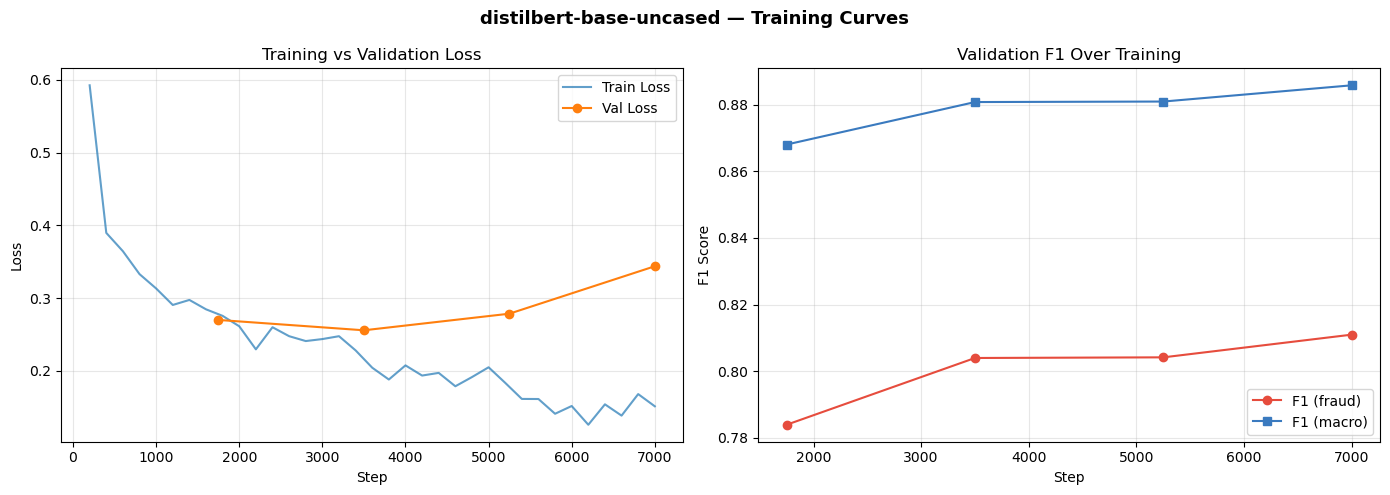

In [16]:
# Plot training loss and eval F1 over epochs
log_history = pd.DataFrame(trainer.state.log_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
train_logs = log_history.dropna(subset=['loss'])
eval_logs  = log_history.dropna(subset=['eval_loss'])

axes[0].plot(train_logs['step'], train_logs['loss'],   label='Train Loss',  alpha=0.7)
axes[0].plot(eval_logs['step'],  eval_logs['eval_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 (fraud)
axes[1].plot(eval_logs['step'], eval_logs['eval_f1_fraud'], marker='o', color='#e64c3d', label='F1 (fraud)')
axes[1].plot(eval_logs['step'], eval_logs['eval_f1_macro'], marker='s', color='#3a7abf', label='F1 (macro)')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation F1 Over Training')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'{MODEL_CHECKPOINT} — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_training_curves.png', dpi=150)
plt.show()

---
## 9. Test Set Evaluation

In [17]:
# Get raw logits from trainer
test_output = trainer.predict(tokenized_datasets['test'])
logits      = test_output.predictions
labels_true = test_output.label_ids

probs_fraud = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
preds_default = np.argmax(logits, axis=-1)

print('='*60)
print(f'  {MODEL_CHECKPOINT} — Test Set Results (threshold = 0.50)')
print('='*60)
print(classification_report(
    labels_true, preds_default,
    target_names=['non-fraud', 'fraud']
))
print(f'ROC-AUC:        {roc_auc_score(labels_true, probs_fraud):.4f}')
print(f'Avg Precision:  {average_precision_score(labels_true, probs_fraud):.4f}')

  distilbert-base-uncased — Test Set Results (threshold = 0.50)
              precision    recall  f1-score   support

   non-fraud       0.96      0.96      0.96      9999
       fraud       0.81      0.82      0.81      2001

    accuracy                           0.94     12000
   macro avg       0.88      0.89      0.89     12000
weighted avg       0.94      0.94      0.94     12000

ROC-AUC:        0.9627
Avg Precision:  0.8855


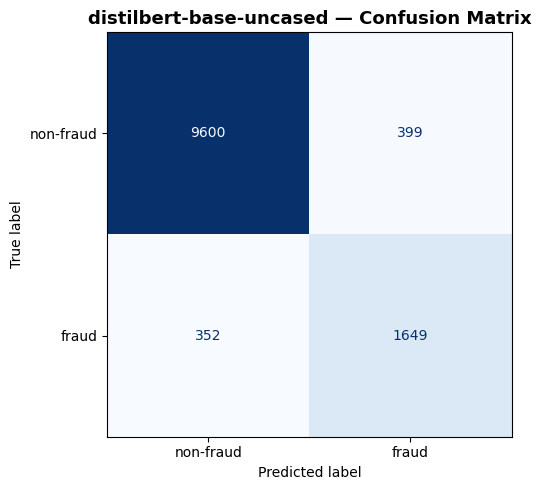

In [18]:
# Confusion matrix
cm = confusion_matrix(labels_true, preds_default)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['non-fraud', 'fraud']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title(f'{MODEL_CHECKPOINT} — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_confusion_matrix.png', dpi=150)
plt.show()

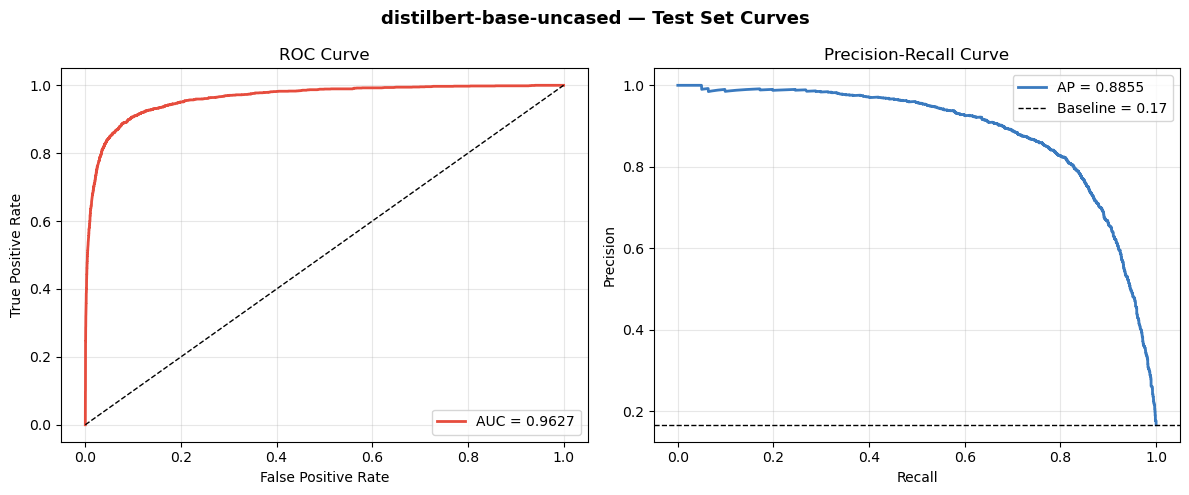

In [19]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(labels_true, probs_fraud)
auc_val = roc_auc_score(labels_true, probs_fraud)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.4f}', color='#e64c3d')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(labels_true, probs_fraud)
ap_val = average_precision_score(labels_true, probs_fraud)
axes[1].plot(rec, prec, lw=2, label=f'AP = {ap_val:.4f}', color='#3a7abf')
axes[1].axhline(labels_true.mean(), color='k', linestyle='--', lw=1, label=f'Baseline = {labels_true.mean():.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'{MODEL_CHECKPOINT} — Test Set Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_roc_pr.png', dpi=150)
plt.show()

---
## 10. Threshold Tuning

Find the probability cutoff that maximizes F1 for the fraud class on the **validation** set, then apply it to test.

Best threshold (val): 0.72
Val F1 (fraud) at best threshold: 0.8142


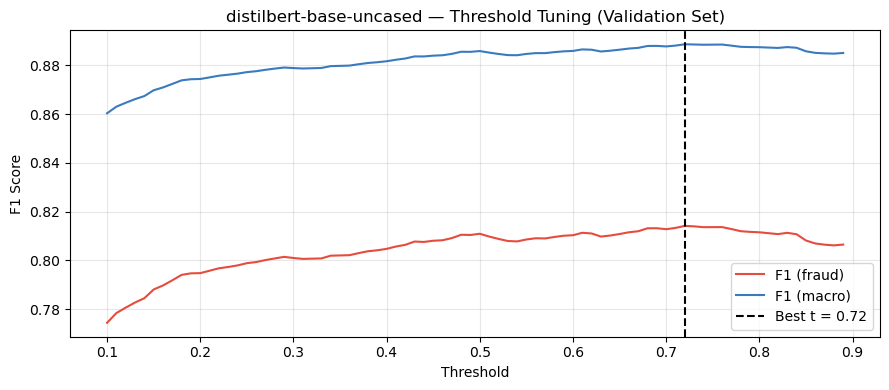

In [20]:
# Get validation probabilities
val_output   = trainer.predict(tokenized_datasets['val'])
val_probs    = torch.softmax(torch.tensor(val_output.predictions), dim=-1).numpy()[:, 1]
val_labels   = val_output.label_ids

thresholds   = np.arange(0.10, 0.90, 0.01)
threshold_results = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    threshold_results.append({
        'threshold': t,
        'f1_fraud':  f1_score(val_labels, preds, pos_label=1, average='binary', zero_division=0),
        'f1_macro':  f1_score(val_labels, preds, average='macro', zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
best_row     = threshold_df.loc[threshold_df['f1_fraud'].idxmax()]
BEST_THRESHOLD = best_row['threshold']

print(f'Best threshold (val): {BEST_THRESHOLD:.2f}')
print(f'Val F1 (fraud) at best threshold: {best_row["f1_fraud"]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(threshold_df['threshold'], threshold_df['f1_fraud'], label='F1 (fraud)', color='#e64c3d')
plt.plot(threshold_df['threshold'], threshold_df['f1_macro'], label='F1 (macro)', color='#3a7abf')
plt.axvline(BEST_THRESHOLD, color='k', linestyle='--', label=f'Best t = {BEST_THRESHOLD:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title(f'{MODEL_CHECKPOINT} — Threshold Tuning (Validation Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_threshold_tuning.png', dpi=150)
plt.show()

In [21]:
# Evaluate on test set with tuned threshold
preds_tuned = (probs_fraud >= BEST_THRESHOLD).astype(int)

print(f'\n{"="*60}')
print(f'  {MODEL_CHECKPOINT} — Test Set (threshold = {BEST_THRESHOLD:.2f})')
print(f'{"="*60}')
print(classification_report(
    labels_true, preds_tuned,
    target_names=['non-fraud', 'fraud']
))


  distilbert-base-uncased — Test Set (threshold = 0.72)
              precision    recall  f1-score   support

   non-fraud       0.96      0.97      0.96      9999
       fraud       0.83      0.80      0.81      2001

    accuracy                           0.94     12000
   macro avg       0.89      0.88      0.89     12000
weighted avg       0.94      0.94      0.94     12000



---
## 11. Error Analysis

Inspect the model's worst mistakes — high-confidence wrong predictions.

In [22]:
error_df = pd.DataFrame({
    'text':       X_test.values,
    'true_label': labels_true,
    'pred_label': preds_tuned,
    'fraud_prob':  probs_fraud,
})

# False Negatives: actual fraud, predicted non-fraud
fn = error_df[(error_df['true_label'] == 1) & (error_df['pred_label'] == 0)]
fn_sorted = fn.sort_values('fraud_prob')   # lowest confidence = most surprising misses

# False Positives: actual non-fraud, predicted fraud
fp = error_df[(error_df['true_label'] == 0) & (error_df['pred_label'] == 1)]
fp_sorted = fp.sort_values('fraud_prob', ascending=False)

print(f'False Negatives (missed fraud): {len(fn):,}')
print(f'False Positives (false alarms):  {len(fp):,}')

False Negatives (missed fraud): 410
False Positives (false alarms):  329


In [23]:
print('\n--- Top 5 False Negatives (missed fraud — lowest fraud probability) ---')
for i, row in fn_sorted.head(5).iterrows():
    print(f"\n[fraud_prob={row['fraud_prob']:.3f}]")
    print(row['text'][:400], '...' if len(row['text']) > 400 else '')


--- Top 5 False Negatives (missed fraud — lowest fraud probability) ---

[fraud_prob=0.002]
As per the guidance from the Consumer Financial Protection Bureau ( CFPB ) the documents needed are a picture ID, a bill, and a letter from an advocacy group helping me due to XXXX XXXXXXXX XXXX XXXX which falls under XXXX  according to XXXXDebt Final Rule 1002.142 ( b ) ( 4 ) -5 -- 1002.142 ( b ) ( 7 ). I kindly request that you block this information from my credit report within four business da ...

[fraud_prob=0.002]
As per the guidance from the Consumer Financial Protection Bureau ( CFPB ) the documents needed are a picture ID, a bill, and a letter from an advocacy group helping me due to XXXX XXXX debt bondage, which falls under trafficking according to Trafficking-Debt Final Rule 1002.142 ( b ) ( 4 ) -5 -- 1002.142 ( b ) ( 7 ). I kindly request that you block this information from my credit report within fo ...

[fraud_prob=0.002]
The inaccuracies on my credit report, including but not l

In [25]:
print('\n--- Top 5 False Positives (false alarms — highest fraud probability) ---')
for i, row in fp_sorted.head(5).iterrows():
    print(f"\n[fraud_prob={row['fraud_prob']:.3f}]")
    print(row['text'][:400], '...' if len(row['text']) > 400 else '')


--- Top 5 False Positives (false alarms — highest fraud probability) ---

[fraud_prob=0.999]
Bank of America honors charges from scam website : The website XXXX XXXX XXXX is a scam. The only number provided ( XXXX ) XXXX only accepts messages. The locations ( addresses on the website ) where I attempted to get this XXXX test for work are invalid and do not honor this company 's registration. Therefore, this bank needs to investigate this matter before accepting the excuses and participati ...

[fraud_prob=0.999]
Capitol One calls me at least 20 times a day in regards to bill I think. I have blocked but they continue to call hundreds of Times in a month. Absolutely tired of it and annoyed 

[fraud_prob=0.999]
I have asked Wells Fargo to stop calling me. They are harassing me. I do not have a history of delinquency. 

[fraud_prob=0.999]
Today, XX/XX/ I answered my cell phone from a XXXX. This person identified himself as XXXX XXXX from XXXX XXXX XXXX, stating that my credit score was go

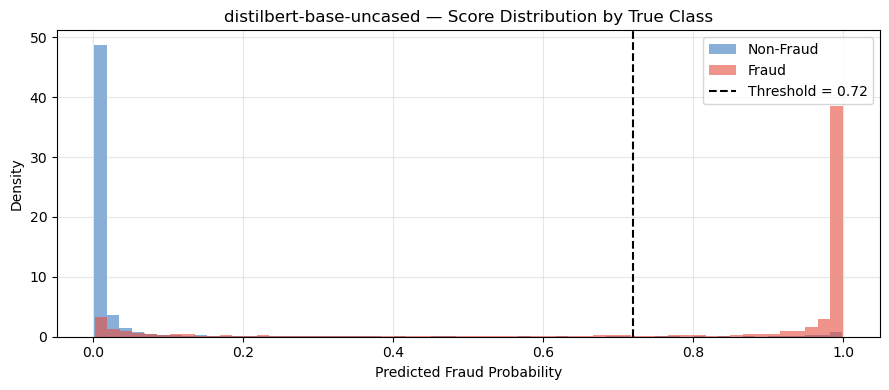

In [26]:
# Probability distribution by true class
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    error_df[error_df['true_label'] == 0]['fraud_prob'],
    bins=60, alpha=0.6, label='Non-Fraud', color='#3a7abf', density=True
)
ax.hist(
    error_df[error_df['true_label'] == 1]['fraud_prob'],
    bins=60, alpha=0.6, label='Fraud', color='#e64c3d', density=True
)
ax.axvline(BEST_THRESHOLD, color='k', linestyle='--', label=f'Threshold = {BEST_THRESHOLD:.2f}')
ax.set_xlabel('Predicted Fraud Probability')
ax.set_ylabel('Density')
ax.set_title(f'{MODEL_CHECKPOINT} — Score Distribution by True Class')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_score_distribution.png', dpi=150)
plt.show()

---
## 12. Save Model & Threshold

In [27]:
# Save model + tokenizer in HuggingFace format
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Save threshold and final metrics
final_metrics = {
    'model':            MODEL_CHECKPOINT,
    'max_len':          MAX_LEN,
    'best_threshold':   float(BEST_THRESHOLD),
    'test_roc_auc':     float(roc_auc_score(labels_true, probs_fraud)),
    'test_avg_precision': float(average_precision_score(labels_true, probs_fraud)),
    'test_f1_fraud':    float(f1_score(labels_true, preds_tuned, pos_label=1, average='binary')),
    'test_f1_macro':    float(f1_score(labels_true, preds_tuned, average='macro')),
}

with open(f'{OUTPUT_DIR}/stage1_bert_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print('Model saved to:', OUTPUT_DIR)
print('Metrics:', json.dumps(final_metrics, indent=2))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./outputs/models/bert_stage1
Metrics: {
  "model": "distilbert-base-uncased",
  "max_len": 512,
  "best_threshold": 0.7199999999999996,
  "test_roc_auc": 0.9626820003339663,
  "test_avg_precision": 0.8855189939324891,
  "test_f1_fraud": 0.8115276715123693,
  "test_f1_macro": 0.8873615248841292
}


---
## 13. Inference Helper

Reusable function for Stage 2 or downstream pipelines.

In [28]:
from transformers import pipeline as hf_pipeline

def load_fraud_detector(model_dir, threshold=None, device=None):
    """
    Load the saved BERT fraud detector.

    Parameters
    ----------
    model_dir : str — path to saved model directory
    threshold : float | None — if None, loads from stage1_bert_metrics.json
    device    : str | None — 'cuda', 'cpu', or None (auto-detect)

    Returns
    -------
    (pipe, threshold)
    """
    if threshold is None:
        with open(f'{model_dir}/stage1_bert_metrics.json') as f:
            threshold = json.load(f)['best_threshold']

    if device is None:
        device = 0 if torch.cuda.is_available() else -1   # HF convention: 0 = cuda:0, -1 = cpu

    pipe = hf_pipeline(
        'text-classification',
        model=model_dir,
        tokenizer=model_dir,
        device=device,
        truncation=True,
        max_length=MAX_LEN,
        return_all_scores=True,
    )
    return pipe, threshold


def predict_fraud_bert(texts, pipe, threshold=0.5):
    """
    Run inference on a list of complaint narratives.

    Returns
    -------
    pd.DataFrame with columns: ['text', 'fraud_prob', 'fraud_pred']
    """
    texts = list(pd.Series(texts).astype(str))
    outputs = pipe(texts, batch_size=64)

    rows = []
    for text, scores in zip(texts, outputs):
        fraud_score = next(s['score'] for s in scores if s['label'] == 'fraud')
        rows.append({
            'text':       text,
            'fraud_prob': fraud_score,
            'fraud_pred': int(fraud_score >= threshold),
        })
    return pd.DataFrame(rows)


# --- Quick sanity check ---
test_complaints = [
    "Someone stole my identity and opened a credit card in my name without my knowledge.",
    "I was charged a late fee even though my payment was submitted on time.",
    "I received a call from someone claiming to be the IRS demanding immediate payment or arrest.",
    "The bank closed my account without any notice or explanation.",
]

bert_pipe, saved_threshold = load_fraud_detector(OUTPUT_DIR)
print(f'Loaded model with threshold = {saved_threshold:.2f}\n')
print(predict_fraud_bert(test_complaints, bert_pipe, threshold=saved_threshold).to_string(index=False))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded model with threshold = 0.72



TypeError: string indices must be integers, not 'str'

---
## 14. Optional: Upgrade to `bert-base-uncased`

If DistilBERT's performance is not sufficient, switch to full BERT by changing one line.

```python
MODEL_CHECKPOINT = 'bert-base-uncased'
```

**Expected tradeoffs vs DistilBERT:**
| | DistilBERT | bert-base-uncased |
|---|---|---|
| Parameters | 66M | 110M |
| Training speed | ~2× faster | baseline |
| VRAM (batch=32) | ~6 GB | ~10–12 GB |
| Typical F1 uplift | — | +0.5–2% |

For most financial complaint NLP tasks, DistilBERT gets you 97–98% of BERT's performance.

### Other model options worth trying
| Checkpoint | Notes |
|---|---|
| `bert-base-uncased` | Full BERT — highest accuracy of the group |
| `roberta-base` | Often outperforms BERT on downstream NLP |
| `ProsusAI/finbert` | Pre-trained on financial text — strong prior for CFPB data |
| `yiyanghkust/finbert-tone` | Fine-tuned financial sentiment — useful transfer starting point |

---
## 15. Next Steps

1. **Compare against baselines** — use `stage1_model_comparison.csv` from `04_stage1_modeling.ipynb`
2. **Full dataset run** — set `USE_SUBSAMPLE = False` and re-train
3. **Try `bert-base-uncased` or `ProsusAI/finbert`** if there's headroom in compute budget
4. **Feed predictions into Stage 2** — use `predict_fraud_bert()` to label fraud-flagged complaints for the multi-class classifier